# Support Vector Machine (SVM)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/ml-mastery/blob/main/02_ml_concepts/svm.ipynb)

---

## Table of Contents
1. [Concept Overview](#1-concept-overview)
2. [Math Intuition](#2-math-intuition)
   - 2.1 The Hyperplane and Decision Rule
   - 2.2 Functional and Geometric Margin
   - 2.3 Hard-Margin SVM — the Optimization Problem
   - 2.4 The Dual Problem and Support Vectors
   - 2.5 Soft-Margin SVM — handling non-separable data
   - 2.6 The Kernel Trick
   - 2.7 Common Kernels
   - 2.8 SVM for Regression (SVR)
3. [Visual Intuition](#3-visual-intuition)
4. [Code from Scratch](#4-code-from-scratch)
5. [Sklearn Implementation](#5-sklearn-implementation)
6. [Common Mistakes](#6-common-mistakes)
7. [Exercises](#7-exercises)


## 1. Concept Overview

SVM finds the **maximum-margin hyperplane** — the decision boundary that is as far as possible from the nearest training points of each class. Those nearest points are called **support vectors**.

**The core idea:** Instead of just finding *any* boundary that separates the classes, SVM finds the one with the largest gap (margin). A wider margin means the model is less sensitive to small perturbations in the data, which leads to better generalization.

**When to use it:**
- High-dimensional data (text classification, genomics)
- Small to medium datasets where training time is acceptable
- When you need a non-linear boundary via the kernel trick
- Binary classification (multiclass via OvO or OvR)

**Strengths:** Effective in high dimensions, memory efficient (only support vectors matter), powerful with kernels, globally optimal solution (convex optimization)

**Weaknesses:** Slow on large datasets ($O(n^2)$ to $O(n^3)$), sensitive to feature scaling, hard to interpret, kernel choice matters a lot


## 2. Math Intuition

### 2.1 The Hyperplane and Decision Rule

A hyperplane in $\mathbb{R}^n$ is defined by:

$$\mathbf{w}^T \mathbf{x} + b = 0$$

where $\mathbf{w}$ is the **normal vector** (perpendicular to the hyperplane) and $b$ is the **bias**.

The decision rule:
$$f(\mathbf{x}) = \text{sign}(\mathbf{w}^T \mathbf{x} + b)$$

- $\mathbf{w}^T \mathbf{x} + b > 0 \implies$ class $+1$
- $\mathbf{w}^T \mathbf{x} + b < 0 \implies$ class $-1$

---

### 2.2 Functional and Geometric Margin

**Functional margin** of a point $(\mathbf{x}_i, y_i)$:

$$\hat{\gamma}_i = y_i(\mathbf{w}^T \mathbf{x}_i + b)$$

A positive functional margin means the point is correctly classified and on the right side of the boundary.

**Geometric margin** (actual Euclidean distance from the point to the hyperplane):

$$\gamma_i = \frac{y_i(\mathbf{w}^T \mathbf{x}_i + b)}{\|\mathbf{w}\|}$$

The **margin of the classifier** is the smallest geometric margin across all training points:

$$\gamma = \min_i \gamma_i = \frac{1}{\|\mathbf{w}\|} \min_i y_i(\mathbf{w}^T \mathbf{x}_i + b)$$

---

### 2.3 Hard-Margin SVM — the Optimization Problem

We want to **maximize the margin** $\frac{2}{\|\mathbf{w}\|}$ (distance between the two parallel margin hyperplanes), subject to all points being correctly classified with margin $\geq 1$:

$$\max_{\mathbf{w}, b} \frac{2}{\|\mathbf{w}\|} \quad \text{subject to} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 \quad \forall i$$

Equivalently (minimizing $\frac{1}{2}\|\mathbf{w}\|^2$ is easier to differentiate):

$$\boxed{\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 \quad \text{subject to} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 \quad \forall i}$$

This is a **convex quadratic program** — has a unique global solution.

The two margin hyperplanes are:
- $\mathbf{w}^T \mathbf{x} + b = +1$ (positive margin boundary)
- $\mathbf{w}^T \mathbf{x} + b = -1$ (negative margin boundary)

Margin width $= \frac{2}{\|\mathbf{w}\|}$

---

### 2.4 The Dual Problem and Support Vectors

Using Lagrangian duality, the primal problem transforms into:

$$\max_{\alpha} \sum_{i=1}^{m} \alpha_i - \frac{1}{2} \sum_{i=1}^{m} \sum_{j=1}^{m} \alpha_i \alpha_j y_i y_j \mathbf{x}_i^T \mathbf{x}_j$$

$$\text{subject to} \quad \alpha_i \geq 0 \quad \text{and} \quad \sum_{i=1}^{m} \alpha_i y_i = 0$$

The KKT conditions tell us:
- $\alpha_i = 0$ for most points — they do not affect the solution at all
- $\alpha_i > 0$ only for points where $y_i(\mathbf{w}^T \mathbf{x}_i + b) = 1$ — these are the **support vectors**

The optimal weight vector:

$$\mathbf{w}^* = \sum_{i: \alpha_i > 0} \alpha_i y_i \mathbf{x}_i$$

**Key insight:** The solution depends only on the support vectors — the points on or closest to the margin. All other training points can be deleted without changing the model.

---

### 2.5 Soft-Margin SVM — Handling Non-Separable Data

Real data is rarely linearly separable. We introduce **slack variables** $\xi_i \geq 0$ that allow points to be inside the margin or even on the wrong side:

$$\min_{\mathbf{w}, b, \xi} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{m} \xi_i$$

$$\text{subject to} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i \quad \text{and} \quad \xi_i \geq 0 \quad \forall i$$

The **regularization parameter $C$** controls the tradeoff:

| $C$ large | $C$ small |
|---|---|
| Small slack allowed | Large slack allowed |
| Narrow margin | Wide margin |
| Fewer misclassifications on training data | More misclassifications tolerated |
| Risk of overfitting | Risk of underfitting |

**Hinge loss interpretation:**
The soft-margin objective is equivalent to minimizing:

$$\frac{1}{m} \sum_{i=1}^{m} \max(0, 1 - y_i f(\mathbf{x}_i)) + \frac{1}{2C} \|\mathbf{w}\|^2$$

where $\max(0, 1 - y_i f(\mathbf{x}_i))$ is the **hinge loss** — zero when a point is correctly classified with margin $\geq 1$, linear penalty otherwise.

---

### 2.6 The Kernel Trick

For non-linear boundaries, we could map data to a higher-dimensional space $\phi(\mathbf{x})$ where it becomes linearly separable. But this can be expensive.

The **kernel trick** exploits the fact that the dual problem only involves dot products $\mathbf{x}_i^T \mathbf{x}_j$. If we replace this with a **kernel function** $K(\mathbf{x}_i, \mathbf{x}_j)$ that implicitly computes the dot product in a high-dimensional (even infinite-dimensional) feature space, we never need to compute $\phi(\mathbf{x})$ explicitly:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^T \phi(\mathbf{x}_j)$$

The decision function becomes:

$$f(\mathbf{x}) = \text{sign}\left(\sum_{i \in SV} \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}) + b\right)$$

A function $K$ is a valid kernel if and only if the **Gram matrix** $[K(\mathbf{x}_i, \mathbf{x}_j)]_{ij}$ is positive semi-definite (Mercer's theorem).

---

### 2.7 Common Kernels

| Kernel | Formula | Use when |
|---|---|---|
| **Linear** | $\mathbf{x}_i^T \mathbf{x}_j$ | Linearly separable, high-dimensional data |
| **Polynomial** | $(\gamma \mathbf{x}_i^T \mathbf{x}_j + r)^d$ | Polynomial feature interactions |
| **RBF (Gaussian)** | $\exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$ | Most common, works for most problems |
| **Sigmoid** | $\tanh(\gamma \mathbf{x}_i^T \mathbf{x}_j + r)$ | Rarely used, not always valid |

**RBF kernel intuition:** $K(\mathbf{x}_i, \mathbf{x}_j) = 1$ when points are identical, decays to 0 as they move apart. $\gamma$ controls how fast the decay happens — larger $\gamma$ = narrower Gaussian = more local influence.

---

### 2.8 SVM for Regression (SVR)

SVR fits a tube of width $2\epsilon$ around the data. Points inside the tube incur zero loss. Points outside get a linear penalty:

$$\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{m}(\xi_i + \xi_i^*)$$

$$\text{subject to} \quad y_i - \mathbf{w}^T \mathbf{x}_i - b \leq \epsilon + \xi_i$$
$$\mathbf{w}^T \mathbf{x}_i + b - y_i \leq \epsilon + \xi_i^*$$
$$\xi_i, \xi_i^* \geq 0$$

The $\epsilon$-insensitive loss: $|y - f(x)|_\epsilon = \max(0, |y - f(x)| - \epsilon)$


## 3. Visual Intuition

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)


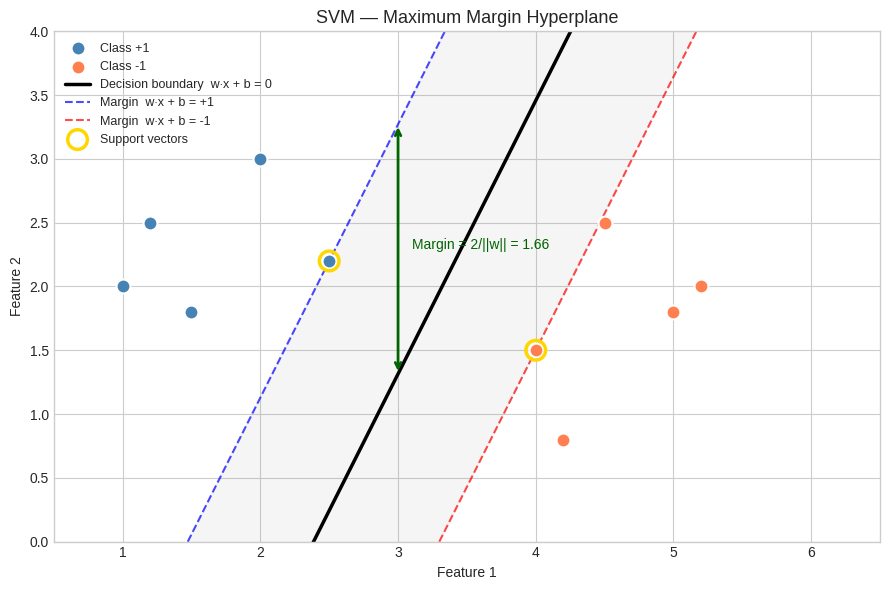

Weight vector w: [-1.095  0.511]
Bias b:          2.613
Number of support vectors: 2
Margin width:    1.6553


In [2]:
# ── Plot 1: Maximum margin hyperplane + support vectors ───────────────────────
from sklearn.svm import SVC
from sklearn.datasets import make_classification

# Linearly separable 2D data
X_lin = np.array([
    [1.0, 2.0],[1.5, 1.8],[2.0, 3.0],[1.2, 2.5],[2.5, 2.2],   # class +1
    [4.0, 1.5],[4.5, 2.5],[5.0, 1.8],[4.2, 0.8],[5.2, 2.0]    # class -1
])
y_lin = np.array([1,1,1,1,1,-1,-1,-1,-1,-1])

svm_lin = SVC(kernel='linear', C=1e6)   # large C = hard margin
svm_lin.fit(X_lin, y_lin)

w  = svm_lin.coef_[0]
b  = svm_lin.intercept_[0]
xx = np.linspace(0, 6.5, 200)

# Decision boundary: w[0]*x + w[1]*y + b = 0  =>  y = (-w[0]*x - b) / w[1]
yy_boundary = -(w[0]*xx + b) / w[1]
yy_pos      = -(w[0]*xx + b - 1) / w[1]   # +1 margin line
yy_neg      = -(w[0]*xx + b + 1) / w[1]   # -1 margin line

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X_lin[y_lin== 1,0], X_lin[y_lin== 1,1],
           c='steelblue', s=100, edgecolors='white', linewidth=1.5,
           zorder=5, label='Class +1')
ax.scatter(X_lin[y_lin==-1,0], X_lin[y_lin==-1,1],
           c='coral', s=100, edgecolors='white', linewidth=1.5,
           zorder=5, label='Class -1')

ax.plot(xx, yy_boundary, 'k-',  linewidth=2.5, label='Decision boundary  w·x + b = 0')
ax.plot(xx, yy_pos,      'b--', linewidth=1.5, alpha=0.7, label='Margin  w·x + b = +1')
ax.plot(xx, yy_neg,      'r--', linewidth=1.5, alpha=0.7, label='Margin  w·x + b = -1')

# Fill margin region
ax.fill_between(xx, yy_neg, yy_pos, alpha=0.08, color='gray')

# Highlight support vectors
sv = svm_lin.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=200, facecolors='none',
           edgecolors='gold', linewidth=2.5, zorder=6, label='Support vectors')

# Margin width annotation
mid_x = 3.0
mid_y_b = -(w[0]*mid_x + b) / w[1]
mid_y_p = -(w[0]*mid_x + b - 1) / w[1]
margin_width = 2 / np.linalg.norm(w)

ax.annotate('', xy=(mid_x, mid_y_p), xytext=(mid_x, mid_y_b),
            arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=2))
ax.text(mid_x + 0.1, (mid_y_b + mid_y_p)/2,
        f'Margin = 2/||w|| = {margin_width:.2f}',
        fontsize=10, color='darkgreen')

ax.set_title("SVM — Maximum Margin Hyperplane", fontsize=13)
ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
ax.set_xlim(0.5, 6.5); ax.set_ylim(0, 4)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Weight vector w: {w.round(3)}")
print(f"Bias b:          {b:.3f}")
print(f"Number of support vectors: {len(sv)}")
print(f"Margin width:    {margin_width:.4f}")


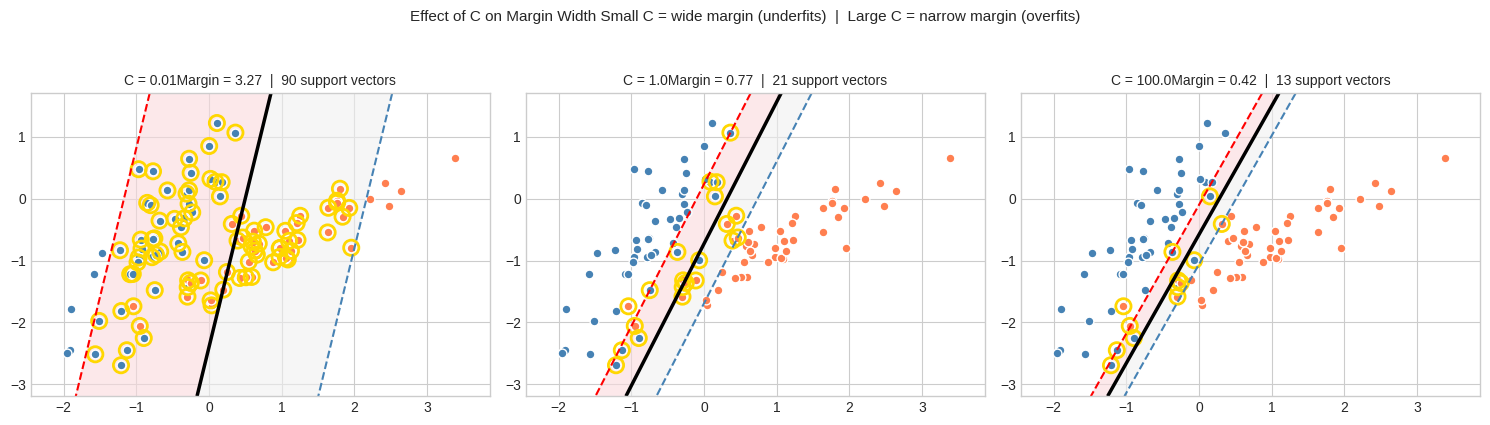

In [3]:
# ── Plot 2: Effect of C on margin width ──────────────────────────────────────
from sklearn.datasets import make_classification

X_c, y_c = make_classification(n_samples=100, n_features=2, n_redundant=0,
                                 n_informative=2, random_state=5,
                                 n_clusters_per_class=1, class_sep=0.8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
C_vals = [0.01, 1.0, 100.0]

for ax, C in zip(axes, C_vals):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X_c, y_c)

    h = 0.02
    x_min, x_max = X_c[:,0].min()-0.5, X_c[:,0].max()+0.5
    y_min, y_max = X_c[:,1].min()-0.5, X_c[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[-1, 0, 1],
                colors=['#FADADD', '#f0f0f0', '#DAE8FC'], alpha=0.6)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               colors=['red','black','steelblue'], linewidths=[1.5, 2.5, 1.5],
               linestyles=['--','-','--'])

    ax.scatter(X_c[y_c==0,0], X_c[y_c==0,1], c='steelblue',
               edgecolors='white', s=40)
    ax.scatter(X_c[y_c==1,0], X_c[y_c==1,1], c='coral',
               edgecolors='white', s=40)
    ax.scatter(clf.support_vectors_[:,0], clf.support_vectors_[:,1],
               s=120, facecolors='none', edgecolors='gold', linewidth=2)

    w = clf.coef_[0]
    margin = 2 / np.linalg.norm(w)
    n_sv   = len(clf.support_vectors_)
    ax.set_title(f"C = {C}Margin = {margin:.2f}  |  {n_sv} support vectors", fontsize=10)

                

plt.suptitle("Effect of C on Margin Width Small C = wide margin (underfits)  |  Large C = narrow margin (overfits)",fontsize=11, y=1.05)

             
plt.tight_layout()
plt.show()


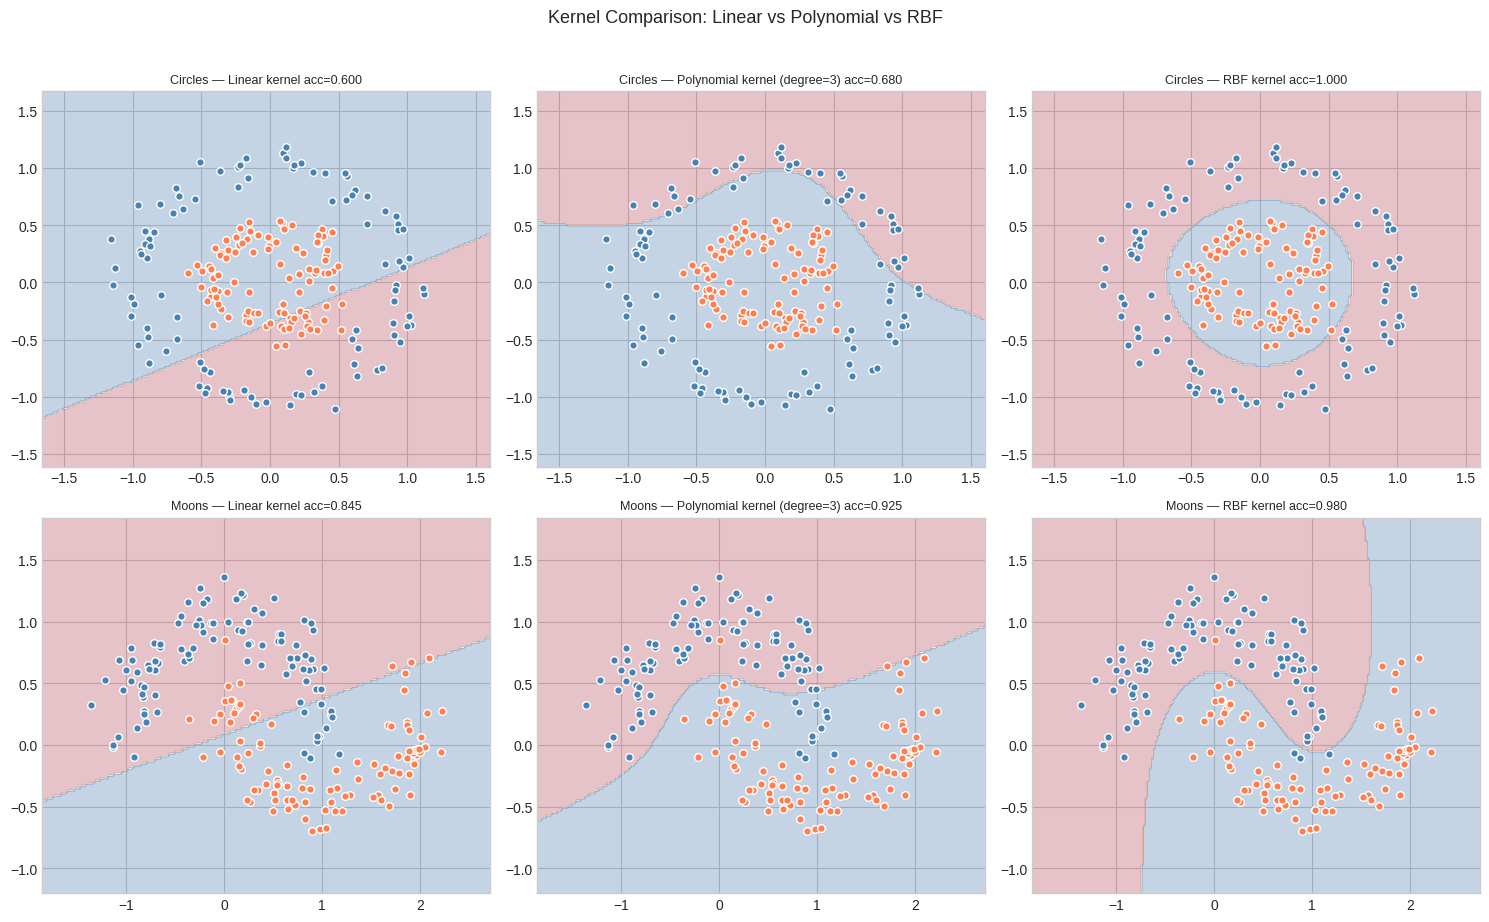

In [4]:
# ── Plot 3: Kernel trick — non-linear boundary ────────────────────────────────
from sklearn.datasets import make_circles, make_moons

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

datasets = [
    (make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42), "Circles"),
    (make_moons(  n_samples=200, noise=0.15, random_state=42),             "Moons"),
]

kernels = ['linear', 'poly', 'rbf']
kernel_labels = ['Linear kernel', 'Polynomial kernel (degree=3)', 'RBF kernel']

for row, ((X_k, y_k), ds_name) in enumerate(datasets):
    for col, (kernel, klabel) in enumerate(zip(kernels, kernel_labels)):
        ax = axes[row, col]
        params = {'degree': 3} if kernel == 'poly' else {}
        clf_k  = SVC(kernel=kernel, C=1.0, gamma='scale', **params)
        clf_k.fit(X_k, y_k)

        h = 0.02
        x_min, x_max = X_k[:,0].min()-0.5, X_k[:,0].max()+0.5
        y_min, y_max = X_k[:,1].min()-0.5, X_k[:,1].max()+0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
        Z = clf_k.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
        ax.scatter(X_k[y_k==0,0], X_k[y_k==0,1], c='steelblue',
                   edgecolors='white', s=30)
        ax.scatter(X_k[y_k==1,0], X_k[y_k==1,1], c='coral',
                   edgecolors='white', s=30)
        acc = clf_k.score(X_k, y_k)
        ax.set_title(f"{ds_name} — {klabel} acc={acc:.3f}", fontsize=9)


plt.suptitle("Kernel Comparison: Linear vs Polynomial vs RBF", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipykernel_21506/1966837692.py:30: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21506/1966837692.py:30: UserWarning: Glyph 7611 (\N{MODIFIER LETTER SMALL Z}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7611 (\N{MODIFIER LETTER SMALL Z}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


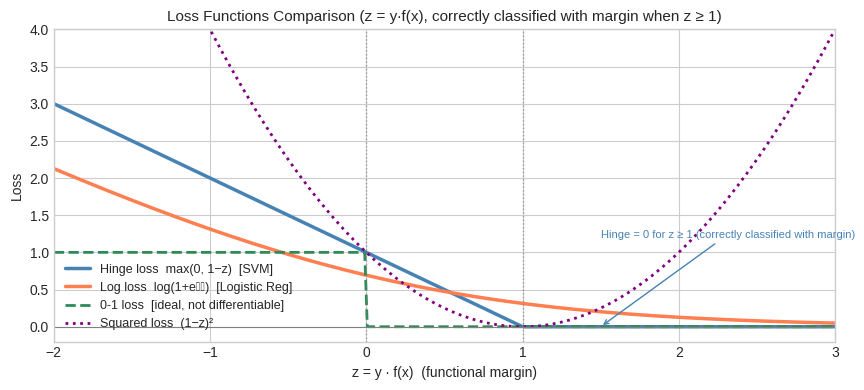

In [5]:
# ── Plot 4: Hinge loss vs other loss functions ────────────────────────────────
z = np.linspace(-2, 3, 300)   # z = y * f(x) = functional margin

hinge    = np.maximum(0, 1 - z)
log_loss = np.log1p(np.exp(-z))
zero_one = (z < 0).astype(float)
squared  = (1 - z)**2

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(z, hinge,    color='steelblue', linewidth=2.5, label='Hinge loss  max(0, 1−z)  [SVM]')
ax.plot(z, log_loss, color='coral',     linewidth=2.5, label='Log loss  log(1+e⁻ᶻ)  [Logistic Reg]')
ax.plot(z, zero_one, color='seagreen',  linewidth=2,   linestyle='--', label='0-1 loss  [ideal, not differentiable]')
ax.plot(z, squared,  color='purple',    linewidth=2,   linestyle=':', label='Squared loss  (1−z)²')

ax.axvline(0, color='gray', linewidth=1, linestyle=':', alpha=0.7)
ax.axvline(1, color='gray', linewidth=1, linestyle=':', alpha=0.7)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title("Loss Functions Comparison (z = y·f(x), correctly classified with margin when z ≥ 1)", fontsize=11)

ax.set_xlabel("z = y · f(x)  (functional margin)")
ax.set_ylabel("Loss")
ax.set_ylim(-0.2, 4)
ax.set_xlim(-2, 3)
ax.legend(fontsize=9)

ax.annotate('Hinge = 0 for z ≥ 1 (correctly classified with margin)', xy=(1.5, 0),

            xytext=(1.5, 1.2), fontsize=8, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'))
plt.tight_layout()
plt.show()


## 4. Code from Scratch

We implement a linear SVM using **gradient descent on the primal problem** (subgradient descent on the hinge loss). This is simpler than the full QP dual solver but gives correct results for linear SVM.

The objective (soft-margin, primal form):

$$J(\mathbf{w}, b) = \frac{1}{m} \sum_{i=1}^{m} \max(0, 1 - y_i(\mathbf{w}^T \mathbf{x}_i + b)) + \frac{\lambda}{2} \|\mathbf{w}\|^2$$

Subgradients:
$$\frac{\partial J}{\partial \mathbf{w}} = \begin{cases} \lambda \mathbf{w} & \text{if } y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 \\ \lambda \mathbf{w} - \frac{1}{m} y_i \mathbf{x}_i & \text{otherwise} \end{cases}$$


In [6]:
class LinearSVMScratch:
    """
    Linear SVM via subgradient descent on the primal hinge loss objective.

    Objective: (1/m) * sum(max(0, 1 - y*(w·x+b))) + (lambda/2)*||w||^2

    Equivalent to sklearn SVC(kernel='linear') with C = 1/lambda.
    """

    def __init__(self, learning_rate=0.001, n_iterations=1000, lambda_=0.01):
        self.lr           = learning_rate
        self.n_iterations = n_iterations
        self.lambda_      = lambda_
        self.w            = None
        self.b            = 0.0
        self.cost_history = []

    def fit(self, X, y):
        m, n       = X.shape
        self.w     = np.zeros(n)
        self.b     = 0.0
        # Convert labels to {-1, +1}
        y_pm = np.where(y == 0, -1, y).astype(float)

        for epoch in range(self.n_iterations):
            margin   = y_pm * (X @ self.w + self.b)   # shape (m,)
            violated = margin < 1                       # hinge active

            # Subgradient
            dw = self.lambda_ * self.w
            db = 0.0
            if violated.any():
                dw -= (y_pm[violated, np.newaxis] * X[violated]).mean(axis=0)
                db -= y_pm[violated].mean()

            self.w -= self.lr * dw
            self.b -= self.lr * db

            # Cost
            hinge = np.maximum(0, 1 - margin).mean()
            cost  = hinge + 0.5 * self.lambda_ * np.dot(self.w, self.w)
            self.cost_history.append(cost)

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, 0)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


Scratch SVM  — Train: 0.9550 | Test: 0.9300


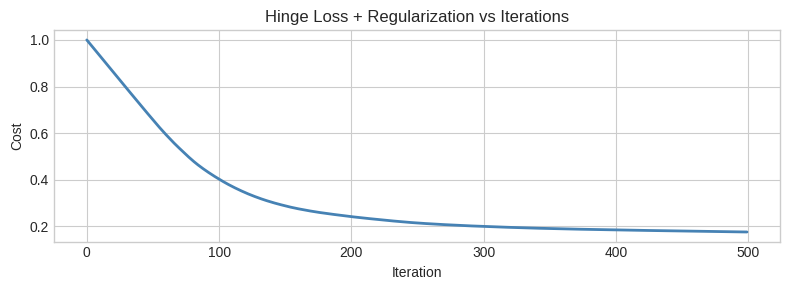

In [7]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_s, y_s = make_classification(n_samples=500, n_features=2, n_redundant=0,
                                 n_informative=2, random_state=42,
                                 n_clusters_per_class=1, class_sep=1.5)

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

# Scale — critical for SVM
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr_s)
X_te_sc = scaler.transform(X_te_s)

svm_sc = LinearSVMScratch(learning_rate=0.01, n_iterations=500, lambda_=0.01)
svm_sc.fit(X_tr_sc, y_tr_s)

print(f"Scratch SVM  — Train: {svm_sc.score(X_tr_sc, y_tr_s):.4f} | Test: {svm_sc.score(X_te_sc, y_te_s):.4f}")

# Cost curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(svm_sc.cost_history, color='steelblue', linewidth=2)
ax.set_title("Hinge Loss + Regularization vs Iterations")
ax.set_xlabel("Iteration"); ax.set_ylabel("Cost")
plt.tight_layout()
plt.show()


In [8]:
# Compare with sklearn
from sklearn.svm import SVC

svm_sk = SVC(kernel='linear', C=1/0.01)   # C = 1/lambda
svm_sk.fit(X_tr_sc, y_tr_s)
print(f"Sklearn SVM  — Train: {svm_sk.score(X_tr_sc, y_tr_s):.4f} | Test: {svm_sk.score(X_te_sc, y_te_s):.4f}")
print(f"  Number of support vectors: {len(svm_sk.support_vectors_)}")
print(f"  (only these {len(svm_sk.support_vectors_)} points define the entire decision boundary)")


Sklearn SVM  — Train: 0.9550 | Test: 0.9500
  Number of support vectors: 52
  (only these 52 points define the entire decision boundary)


## 5. Sklearn Implementation

In [9]:
from sklearn.svm import SVC, SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report
import warnings; warnings.filterwarnings('ignore')

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)

# Pipeline handles scaling automatically
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(
        kernel='rbf',       # 'linear', 'poly', 'rbf', 'sigmoid'
        C=1.0,              # regularization — larger C = smaller margin, fits harder
        gamma='scale',      # 'scale' = 1/(n_features*X.var()), 'auto' = 1/n_features
        probability=True,   # enable predict_proba (uses Platt scaling, slightly slower)
        random_state=42
    ))
])

pipe.fit(X_train, y_train)
print("SVM (RBF kernel) — Breast Cancer Dataset")
print(f"  Train: {pipe.score(X_train, y_train):.4f} | Test: {pipe.score(X_test, y_test):.4f}")
print()
print(classification_report(y_test, pipe.predict(X_test), target_names=data.target_names))


SVM (RBF kernel) — Breast Cancer Dataset
  Train: 0.9824 | Test: 0.9825

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [10]:
# GridSearchCV for C and gamma (the two most important RBF hyperparameters)
param_grid = {
    'svm__C':     [0.01, 0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
}

grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('svm',    SVC(kernel='rbf', probability=True, random_state=42))]),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best CV accuracy:  {grid.best_score_:.4f}")
print(f"Test  accuracy:    {grid.best_estimator_.score(X_test, y_test):.4f}")


Best parameters: {'svm__C': 10, 'svm__gamma': 0.01}
Best CV accuracy:  0.9802
Test  accuracy:    0.9825


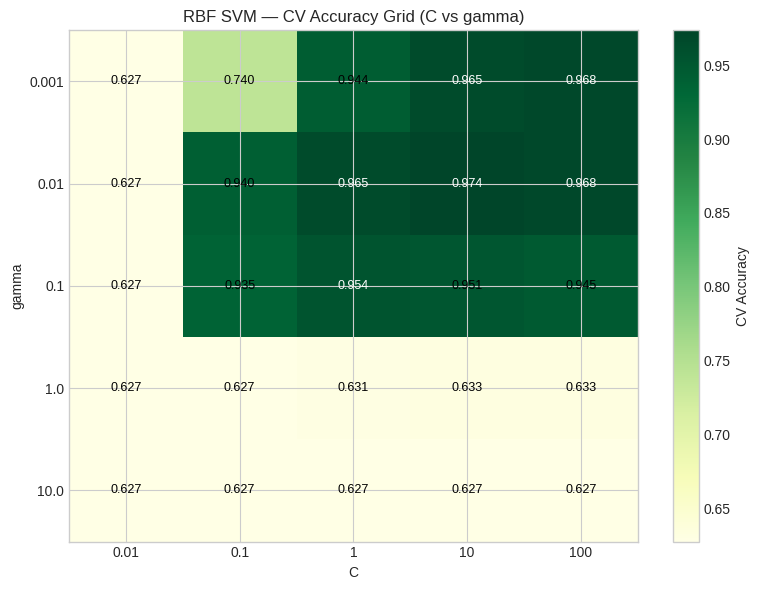

In [11]:
# Heatmap of C vs gamma performance
import warnings; warnings.filterwarnings('ignore')

C_vals     = [0.01, 0.1, 1, 10, 100]
gamma_vals = [0.001, 0.01, 0.1, 1.0, 10.0]
scores     = np.zeros((len(gamma_vals), len(C_vals)))

for i, g in enumerate(gamma_vals):
    for j, c in enumerate(C_vals):
        pipe_cg = Pipeline([
            ('sc',  StandardScaler()),
            ('svm', SVC(kernel='rbf', C=c, gamma=g, random_state=42))
        ])
        cv = cross_val_score(pipe_cg, X, y, cv=3, scoring='accuracy', n_jobs=-1)
        scores[i, j] = cv.mean()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(scores, cmap='YlGn', aspect='auto',
               vmin=scores.min(), vmax=scores.max())
plt.colorbar(im, ax=ax, label='CV Accuracy')

ax.set_xticks(range(len(C_vals)))
ax.set_yticks(range(len(gamma_vals)))
ax.set_xticklabels([str(c) for c in C_vals])
ax.set_yticklabels([str(g) for g in gamma_vals])
ax.set_xlabel("C")
ax.set_ylabel("gamma")
ax.set_title("RBF SVM — CV Accuracy Grid (C vs gamma)")

for i in range(len(gamma_vals)):
    for j in range(len(C_vals)):
        ax.text(j, i, f'{scores[i,j]:.3f}', ha='center', va='center',
                fontsize=9, color='black' if scores[i,j] < scores.max()-0.02 else 'white')

plt.tight_layout()
plt.show()


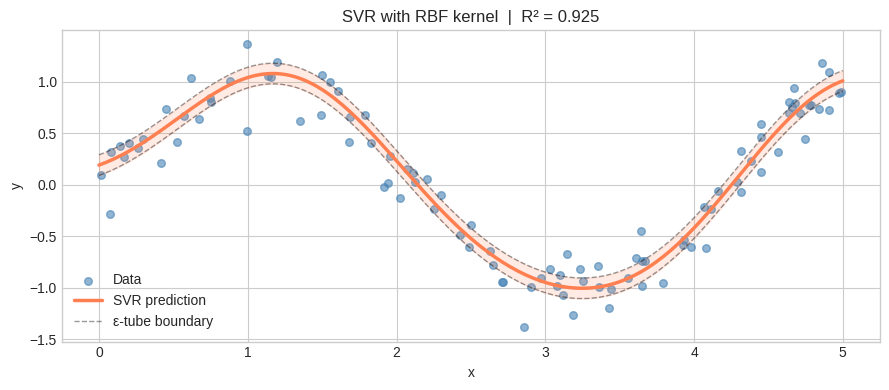

In [12]:
# SVR — SVM for regression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

rng2 = np.random.default_rng(0)
X_reg = rng2.uniform(0, 5, (100, 1))
y_reg = np.sin(X_reg[:,0] * 1.5) + rng2.normal(0, 0.2, 100)

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=0)

svr_pipe = Pipeline([
    ('sc',  StandardScaler()),
    ('svr', SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'))
])
svr_pipe.fit(X_tr_r, y_tr_r)

x_plot = np.linspace(0, 5, 200).reshape(-1,1)
y_plot = svr_pipe.predict(x_plot)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(X_reg, y_reg, color='steelblue', s=30, alpha=0.6, label='Data')
ax.plot(x_plot, y_plot, color='coral', linewidth=2.5, label='SVR prediction')
ax.plot(x_plot, y_plot + svr_pipe.named_steps['svr'].epsilon,
        'k--', linewidth=1, alpha=0.4, label='ε-tube boundary')
ax.plot(x_plot, y_plot - svr_pipe.named_steps['svr'].epsilon,
        'k--', linewidth=1, alpha=0.4)
ax.fill_between(x_plot[:,0],
                y_plot - svr_pipe.named_steps['svr'].epsilon,
                y_plot + svr_pipe.named_steps['svr'].epsilon,
                alpha=0.15, color='coral')
ax.set_title(f"SVR with RBF kernel  |  R² = {r2_score(y_te_r, svr_pipe.predict(X_te_r)):.3f}")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Common Mistakes

In [13]:
# MISTAKE 1: Not scaling features — SVM is extremely sensitive to scale
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

X_m, y_m = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                 random_state=7, n_clusters_per_class=1)
# Artificially create scale mismatch
X_m[:,1] = X_m[:,1] * 1000

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(X_m, y_m, test_size=0.3, random_state=0)

svm_no_scale = SVC(kernel='rbf', C=1, gamma='scale')
svm_no_scale.fit(X_tr_m, y_tr_m)

pipe_scaled = Pipeline([('sc', StandardScaler()), ('svm', SVC(kernel='rbf', C=1, gamma='scale'))])
pipe_scaled.fit(X_tr_m, y_tr_m)

print("Effect of feature scaling on SVM:")
print(f"  Without scaling: test acc = {svm_no_scale.score(X_te_m, y_te_m):.4f}")
print(f"  With scaling:    test acc = {pipe_scaled.score(X_te_m, y_te_m):.4f}")
print("\nAlways use StandardScaler inside a Pipeline before SVM.")


Effect of feature scaling on SVM:
  Without scaling: test acc = 0.8333
  With scaling:    test acc = 0.9667

Always use StandardScaler inside a Pipeline before SVM.


In [14]:
# MISTAKE 2: Using SVC for large datasets — it scales O(n^2) to O(n^3)
# Use LinearSVC or SGDClassifier(loss='hinge') for large data instead.

import time
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier

X_big, y_big = make_classification(n_samples=10000, n_features=20,
                                    n_informative=10, random_state=0)

timings = {}
for name, clf in [
    ('SVC(kernel=rbf)',    SVC(kernel='rbf',   random_state=0)),
    ('LinearSVC',          LinearSVC(max_iter=2000, random_state=0)),
    ('SGD(hinge)',         SGDClassifier(loss='hinge', random_state=0)),
]:
    sc = StandardScaler()
    X_sc = sc.fit_transform(X_big)
    t0 = time.time()
    clf.fit(X_sc, y_big)
    timings[name] = time.time() - t0

print("Training time on 10,000 samples:")
for name, t in timings.items():
    print(f"  {name:<25}: {t:.2f}s")
print("\nUse LinearSVC or SGD for large datasets — SVC(rbf) is O(n²) to O(n³).")


Training time on 10,000 samples:
  SVC(kernel=rbf)          : 1.66s
  LinearSVC                : 0.02s
  SGD(hinge)               : 0.07s

Use LinearSVC or SGD for large datasets — SVC(rbf) is O(n²) to O(n³).


In [15]:
# MISTAKE 3: Forgetting probability=True when you need predict_proba
# SVC does not output probabilities by default.
# probability=True uses Platt scaling (5-fold CV internally) — slower training.

svm_no_prob  = SVC(kernel='rbf', probability=False)
svm_with_prob = SVC(kernel='rbf', probability=True)

sc3 = StandardScaler()
X_tr_p = sc3.fit_transform(X_tr_s)

svm_no_prob.fit(X_tr_p, y_tr_s)
svm_with_prob.fit(X_tr_p, y_tr_s)

try:
    svm_no_prob.predict_proba(X_te_sc)
except AttributeError as e:
    print(f"Without probability=True:  {e}")

proba = svm_with_prob.predict_proba(X_te_sc)
print(f"With probability=True:     predict_proba shape = {proba.shape}")
print(f"First 3 probability pairs: {proba[:3].round(3)}")
print("\nNote: probability=True makes training slower due to internal cross-validation.")


Without probability=True:  This 'SVC' has no attribute 'predict_proba'
With probability=True:     predict_proba shape = (100, 2)
First 3 probability pairs: [[0.081 0.919]
 [0.045 0.955]
 [0.98  0.02 ]]

Note: probability=True makes training slower due to internal cross-validation.


## 7. Exercises

**Exercise 1:** For a linear SVM, compute the margin width manually. Given:
- $\mathbf{w} = [0.5, -1.0]$, $b = 0.3$
- Verify which of these points are support vectors (satisfy $y_i(\mathbf{w}^T \mathbf{x}_i + b) = 1$):
  - $\mathbf{x}_1 = [1, 1]$, $y_1 = +1$
  - $\mathbf{x}_2 = [3, 2]$, $y_2 = -1$
  - $\mathbf{x}_3 = [2, 0]$, $y_3 = +1$


In [16]:
# Your code here


In [17]:
# Solution
w = np.array([0.5, -1.0])
b = 0.3

points = [
    (np.array([1.0, 1.0]),  1,  'x1'),
    (np.array([3.0, 2.0]), -1,  'x2'),
    (np.array([2.0, 0.0]),  1,  'x3'),
]

margin_width = 2 / np.linalg.norm(w)
print(f"||w|| = {np.linalg.norm(w):.4f}")
print(f"Margin width = 2/||w|| = {margin_width:.4f}")
print()

for x, y, name in points:
    functional_margin = y * (w @ x + b)
    is_sv = np.isclose(functional_margin, 1.0, atol=0.01)
    print(f"{name}: w·x+b = {w@x+b:.3f}  |  y*(w·x+b) = {functional_margin:.3f}  "
          f"|  Support vector: {is_sv}")


||w|| = 1.1180
Margin width = 2/||w|| = 1.7889

x1: w·x+b = -0.200  |  y*(w·x+b) = -0.200  |  Support vector: False
x2: w·x+b = -0.200  |  y*(w·x+b) = 0.200  |  Support vector: False
x3: w·x+b = 1.300  |  y*(w·x+b) = 1.300  |  Support vector: False


**Exercise 2:** Compare SVC with `kernel='linear'`, `kernel='poly'` (degree=3), and `kernel='rbf'` on the moons dataset. For each:
- Report train and test accuracy
- Plot the decision boundary
- Report number of support vectors


In [18]:
# Your code here


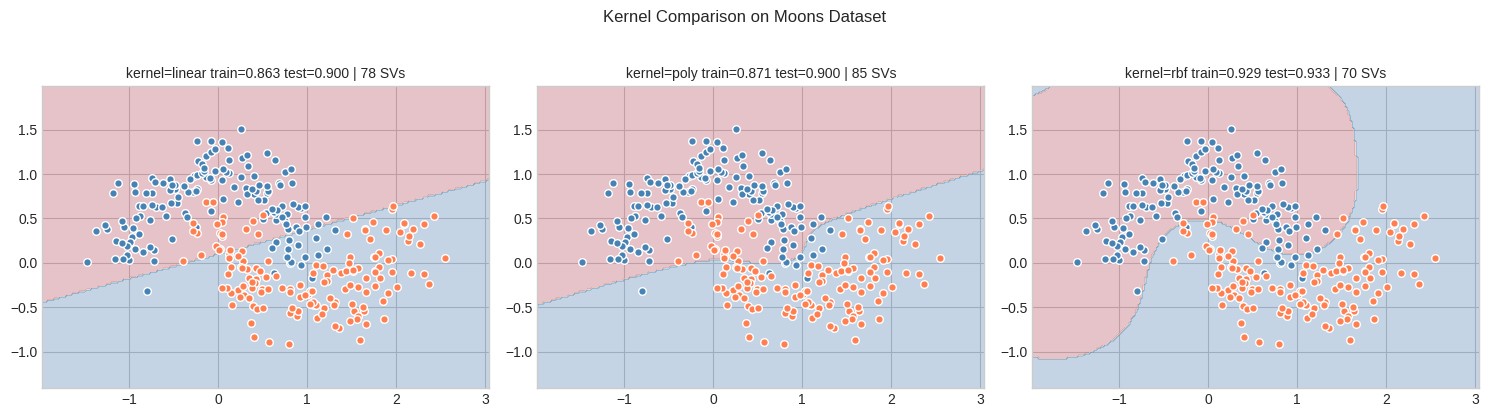

In [19]:
# Solution
from sklearn.datasets import make_moons

X_mn, y_mn = make_moons(n_samples=300, noise=0.2, random_state=42)
X_tr_mn, X_te_mn, y_tr_mn, y_te_mn = train_test_split(X_mn, y_mn,
                                                        test_size=0.2, random_state=42)

kernels_params = [
    ('linear', {}),
    ('poly',   {'degree': 3}),
    ('rbf',    {'gamma': 'scale'}),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
h = 0.02

for ax, (kernel, params) in zip(axes, kernels_params):
    pipe_k = Pipeline([
        ('sc',  StandardScaler()),
        ('svm', SVC(kernel=kernel, C=1.0, **params))
    ])
    pipe_k.fit(X_tr_mn, y_tr_mn)

    x_min, x_max = X_mn[:,0].min()-0.5, X_mn[:,0].max()+0.5
    y_min, y_max = X_mn[:,1].min()-0.5, X_mn[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = pipe_k.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
    ax.scatter(X_mn[y_mn==0,0], X_mn[y_mn==0,1], c='steelblue',
               edgecolors='white', s=30)
    ax.scatter(X_mn[y_mn==1,0], X_mn[y_mn==1,1], c='coral',
               edgecolors='white', s=30)

    tr_acc = pipe_k.score(X_tr_mn, y_tr_mn)
    te_acc = pipe_k.score(X_te_mn, y_te_mn)
    n_sv   = pipe_k.named_steps['svm'].n_support_.sum()
    ax.set_title(f"kernel={kernel} train={tr_acc:.3f} test={te_acc:.3f} | {n_sv} SVs", fontsize=10)

                 

plt.suptitle("Kernel Comparison on Moons Dataset", fontsize=12, y=1.03)
plt.tight_layout()
plt.show()


**Exercise 3:** The hinge loss is defined as $L(z) = \max(0, 1-z)$ where $z = y \cdot f(x)$.

Implement a function that computes the **subgradient** of the hinge loss, then use it to manually perform 3 gradient descent steps on a single misclassified point. Show the weight vector and loss at each step.


In [20]:
# Your code here


In [21]:
# Solution
def hinge_loss(w, b, x, y, lambda_reg=0.01):
    z = y * (w @ x + b)
    return max(0, 1 - z) + 0.5 * lambda_reg * np.dot(w, w)

def hinge_subgradient(w, b, x, y, lambda_reg=0.01):
    z = y * (w @ x + b)
    if z >= 1:   # correctly classified with margin — only regularization grad
        dw = lambda_reg * w
        db = 0.0
    else:        # violated margin — hinge gradient + regularization
        dw = lambda_reg * w - y * x
        db = -y
    return dw, db

# Single misclassified point
x_ex = np.array([2.0, 3.0])
y_ex = 1
w_ex = np.array([-0.5, -0.5])   # bad initial weights
b_ex = 0.0
lr_ex = 0.1

print(f"{'Step':<6}  {'w':>20}  {'b':>6}  {'Loss':>8}  {'z=y*f(x)':>10}")
for step in range(4):
    loss = hinge_loss(w_ex, b_ex, x_ex, y_ex)
    z    = y_ex * (w_ex @ x_ex + b_ex)
    print(f"{step:<6}  {str(w_ex.round(4)):>20}  {b_ex:>6.3f}  {loss:>8.4f}  {z:>10.4f}")
    dw, db = hinge_subgradient(w_ex, b_ex, x_ex, y_ex)
    w_ex = w_ex - lr_ex * dw
    b_ex = b_ex - lr_ex * db

print("\nAfter 3 steps the point is being pushed toward the correct side.")


Step                       w       b      Loss    z=y*f(x)
0                [-0.5 -0.5]   0.000    3.5025     -2.5000
1          [-0.2995 -0.1995]   0.100    2.0981     -1.0975
2          [-0.0992  0.1007]   0.200    0.6964      0.3037
3            [0.1009 0.4006]   0.300    0.0009      1.7036

After 3 steps the point is being pushed toward the correct side.


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
